### Data loading and Basic overview if dataset 

This dataset contains information on individuals with various attributes related to their personal and lifestyle factors. It is designed to facilitate analysis in areas such as health, lifestyle, and socio-economic status.

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = ""

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "anthonytherrien/depression-dataset",
  "depression_data.csv",
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/Users/bhaskarrai/Desktop/EDA/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/_r/kzj9vwk94h71mvpxy8m6nj_m0000gn/T/ipykernel_32137/2446393973.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [3]:
display(df.head())
display(df.tail())

display(df.shape)

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
413763,Sean Miller,68,Married,Master's Degree,0,Former,Moderate,Employed,109233.43,Low,Healthy,Good,No,No,No,No
413764,Christina Brown,26,Single,Bachelor's Degree,0,Current,Active,Employed,96760.97,Low,Healthy,Poor,Yes,Yes,No,Yes
413765,Matthew Jenkins,57,Married,Bachelor's Degree,0,Non-smoker,Sedentary,Employed,77353.26,Moderate,Moderate,Fair,No,No,Yes,Yes
413766,Gary Faulkner,71,Married,Associate Degree,2,Non-smoker,Sedentary,Unemployed,24557.08,Moderate,Moderate,Poor,No,Yes,No,No
413767,Joseph Johnson,62,Widowed,Master's Degree,0,Former,Moderate,Employed,107125.74,Moderate,Healthy,Good,No,Yes,No,No


(413768, 16)

### Null values

In [5]:
df.isnull().sum()

Name                            0
Age                             0
Marital Status                  0
Education Level                 0
Number of Children              0
Smoking Status                  0
Physical Activity Level         0
Employment Status               0
Income                          0
Alcohol Consumption             0
Dietary Habits                  0
Sleep Patterns                  0
History of Mental Illness       0
History of Substance Abuse      0
Family History of Depression    0
Chronic Medical Conditions      0
dtype: int64

### Features:

In [9]:
categorical_features = df.select_dtypes(["object","string"]).columns
numerical_features = df.select_dtypes(["int","float"]).columns

print(f"Total features:{len(df.columns)}")
print(f"\n Numerical features:{numerical_features}")
print(f"Categorical features:{categorical_features}")

Total features:16

 Numerical features:Index(['Age', 'Number of Children', 'Income'], dtype='str')
Categorical features:Index(['Name', 'Marital Status', 'Education Level', 'Smoking Status',
       'Physical Activity Level', 'Employment Status', 'Alcohol Consumption',
       'Dietary Habits', 'Sleep Patterns', 'History of Mental Illness',
       'History of Substance Abuse', 'Family History of Depression',
       'Chronic Medical Conditions'],
      dtype='str')


### Target column:
Chronic Medical Conditions

,target_columns
Chronic Medical Conditions,
No,277561
Yes,136207


,target_columns
Chronic Medical Conditions,
No,67.08
Yes,32.92


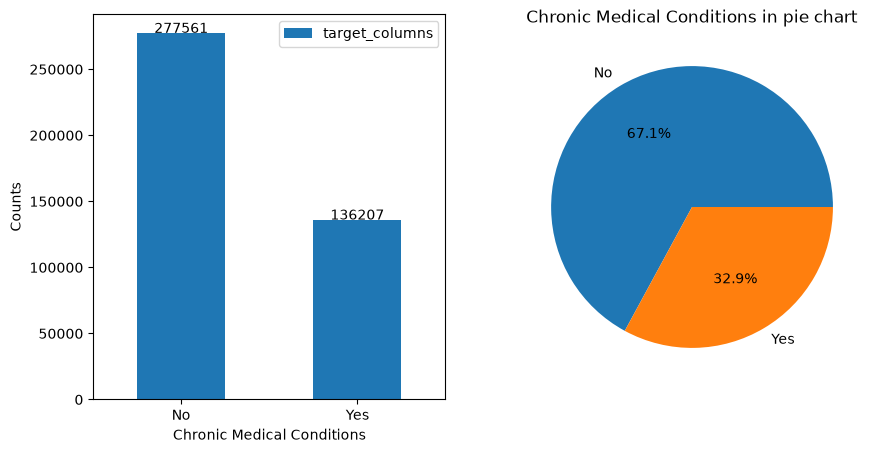

In [5]:
X = df.drop(columns="Chronic Medical Conditions")
y = df["Chronic Medical Conditions"]


# subplot
fig,ax = plt.subplots(1,2,figsize=(10,5))


# # summmary of target columns 
target_summary = pd.DataFrame({
    "target_columns":y.value_counts()
})
target_summary_percentage = pd.DataFrame({
    "target_columns":(y.value_counts(normalize=True)*100).round(2)
})

display(target_summary) # discrete value 
display(target_summary_percentage) # percentage value 

# bar plot the taget summary
target_summary.plot(
    kind = "bar",
    ax=ax[0]
)

for i,value in enumerate(target_summary.values):
    ax[0].text(i,value[0],f"{value[0]}",ha="center")
ax[0].tick_params(rotation=0)
ax[0].set_ylabel("Counts")


# pie chart of target columns
ax[1].pie(
    x=df["Chronic Medical Conditions"].value_counts().values,
    labels = df["Chronic Medical Conditions"].value_counts().index ,
    autopct="%1.1f%%"
) 
ax[1].set_title("Chronic Medical Conditions in pie chart")
plt.show()



The value count of taget varailable is a little bit unbalance. Around 67% belong to No class and around 33% belong to Yes class. 

### Univaraint analysis

Name 
+ Individuel person name

In [ ]:
len(X["Name"].unique())

196851

Out of 413768 only 196851 are only unique name. Most of the names are repeated. So let's see those repeated name have similar data or not.

In [73]:
X["Name"].value_counts()

Name
Michael Smith      198
Michael Johnson    147
David Smith        131
Robert Smith       128
David Johnson      126
                  ... 
Amy Haley            1
Karl Elliott         1
Madeline Butler      1
Travis Brewer        1
Gary Faulkner        1
Name: count, Length: 196851, dtype: int64

In [77]:
name_1 = df.loc[df["Name"]=="Michael Smith"]
name_2 = df.loc[df["Name"]== "Michael Johnson"]

display(name_1.head())
display(name_2.head())

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
1717,Michael Smith,60,Widowed,High School,0,Former,Sedentary,Employed,41818.81,Low,Unhealthy,Good,Yes,No,No,No
3301,Michael Smith,33,Married,Master's Degree,1,Former,Sedentary,Unemployed,7321.08,High,Unhealthy,Fair,No,No,No,Yes
7790,Michael Smith,80,Married,PhD,2,Non-smoker,Sedentary,Unemployed,3437.34,High,Moderate,Fair,Yes,No,No,No
7987,Michael Smith,20,Single,High School,0,Current,Active,Unemployed,5062.26,Low,Moderate,Fair,Yes,Yes,No,No
10884,Michael Smith,50,Married,Associate Degree,0,Non-smoker,Active,Employed,60134.87,Moderate,Moderate,Good,No,Yes,No,No


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
9016,Michael Johnson,41,Married,Associate Degree,2,Current,Sedentary,Employed,61316.84,Low,Unhealthy,Fair,No,No,Yes,No
9184,Michael Johnson,36,Married,High School,3,Former,Moderate,Employed,33195.57,Low,Unhealthy,Fair,No,No,Yes,No
10398,Michael Johnson,44,Widowed,Master's Degree,2,Former,Moderate,Employed,93427.09,High,Healthy,Good,Yes,No,No,Yes
13557,Michael Johnson,26,Married,Master's Degree,1,Current,Sedentary,Employed,91287.26,High,Healthy,Poor,No,No,No,No
15246,Michael Johnson,80,Married,PhD,1,Former,Moderate,Employed,199123.94,High,Healthy,Fair,No,No,No,No


From this above data we can conclude that those repeated name are n't same. Later during hte feature engineering we are droping this features because of huge number of unique value. 

### Age
Age of individual user

,age
count,413768.000000
mean,49.000713
std,18.158759
min,18.000000
25%,33.000000
50%,49.000000
75%,65.000000
max,80.000000


,age_bin_summary
age-bins,
18-30,85251
40-50,66017
50-60,65888
60-70,65656
30-40,65505
70-80,65451


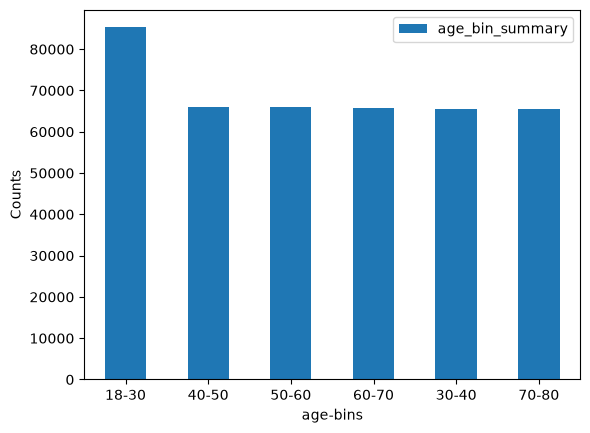

In [104]:
age_summary = pd.DataFrame({
    "age":X["Age"].describe()
})

# displaying the summary of age
display(age_summary)

# dividing the age group in certain interval 
X["age-bins"] = pd.cut(
    x=X["Age"],
    bins = [18,30,40,50,60,70,80],
    labels=["18-30","30-40","40-50","50-60","60-70","70-80"],
    include_lowest=True
)

age_bin_summary = pd.DataFrame({
    "age_bin_summary":X["age-bins"].value_counts()
})

display(age_bin_summary)
age_bin_summary.plot(
    kind="bar"
)
plt.xticks(rotation=0)
plt.ylabel("Counts")
plt.show()


We can visaulize that each age group have almost equal number of users.

In [109]:
# realtion with target values
age_target_column = df.groupby("Chronic Medical Conditions")["Age"].describe()
display(age_target_column)

,count,mean,std,min,25%,50%,75%,max
Chronic Medical Conditions,,,,,,,,
No,277561.0,49.224916,18.133276,18.0,34.0,49.0,65.0,80.0
Yes,136207.0,48.543834,18.202099,18.0,33.0,48.0,64.0,80.0


So the distribution of age similar for both class. So age features doesn't appear as a strong features to seperate the class.

**Marital Status**:<br>
The marital status of the individual. Possible values include Single, Married, Divorced, and Widowed.

,marital_status
Marital Status,
Married,240444
Single,72110
Widowed,68485
Divorced,32729


<Figure size 1000x1000 with 0 Axes>

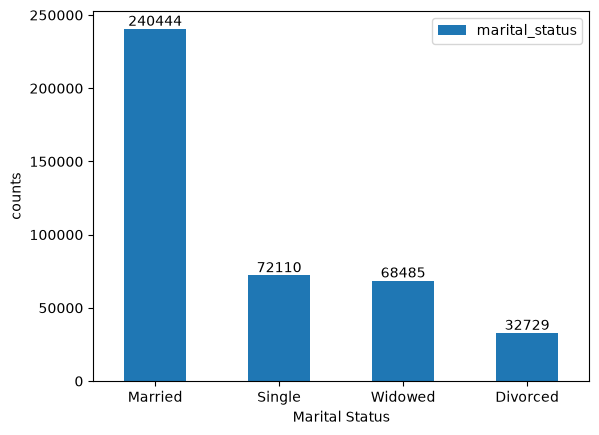

In [6]:
marital_status= pd.DataFrame({
    "marital_status":X["Marital Status"].value_counts()
})


display(marital_status)

plt.figure(figsize=(10,10))
# plotting the all martial status
marital_status.plot(
    kind="bar"
)

for i,value in enumerate(marital_status.values):
    plt.text(i,value[0],f"{value[0]}",ha="center",va="bottom")
plt.xticks(rotation=0)
plt.ylabel("counts")
plt.show()

Chronic Medical Conditions,No,Yes
Marital Status,,
Divorced,0.672065,0.327935
Married,0.672302,0.327698
Single,0.658577,0.341423
Widowed,0.677871,0.322129


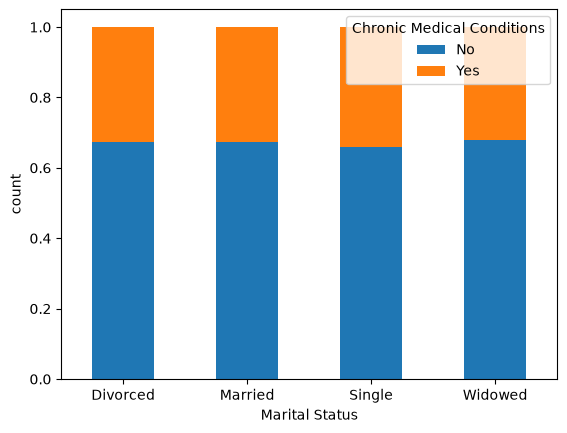

In [21]:
# marital status with target columns 
marital_status_target = pd.crosstab(
    X["Marital Status"],
    df["Chronic Medical Conditions"],
    normalize="index"
)
display(marital_status_target)

marital_status_target.plot(
    kind="bar",
    stacked=True,
)
plt.xticks(rotation=0)
plt.ylabel("count")
plt.show()

With the help of this given figure we can see that for each marital status there is the equal number of Chronic Medical Conditions.

**Education Level**:<br>
The highest level of education attained by the individual. Possible values include High School, Associate Degree, Bachelor's Degree, Master's Degree, and PhD.

,education
Education Level,
Bachelor's Degree,124329
High School,118927
Associate Degree,79999
Master's Degree,73768
PhD,16745


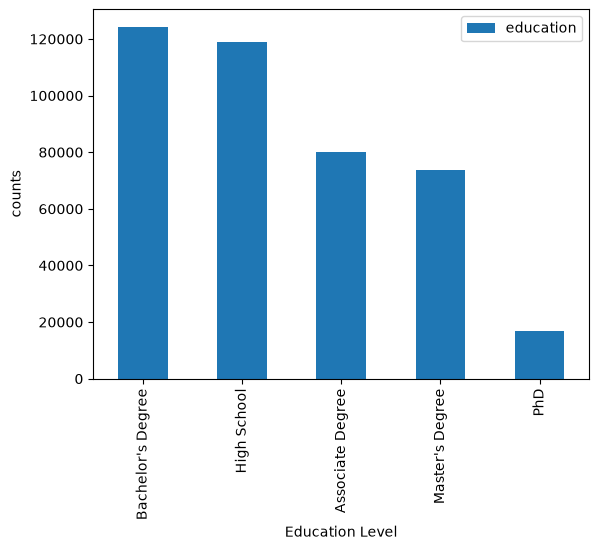

In [18]:
education_col_summary = pd.DataFrame({
    "education":X["Education Level"].value_counts()
})

display(education_col_summary)

education_col_summary.plot(
    kind="bar"
)
plt.ylabel("counts")
plt.show()

With the help of this figure we can see that maximum number of user has completed the Bachelor degree and high school. Least number of user has completed phd.

Chronic Medical Conditions,No,Yes
Education Level,,
Associate Degree,0.669908,0.330092
Bachelor's Degree,0.672007,0.327993
High School,0.668763,0.331237
Master's Degree,0.672961,0.327039
PhD,0.671365,0.328635


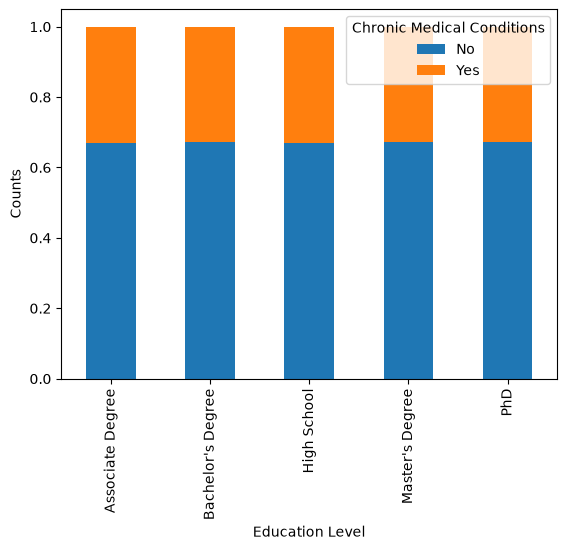

In [23]:
# realtion with target column
education_with_target = pd.crosstab(
    df["Education Level"],
    df["Chronic Medical Conditions"],
    normalize="index"
)
display(education_with_target)


education_with_target.plot(kind="bar",stacked=True)
plt.ylabel("Counts")
plt.show()

For each level of education the percentage of Chronic Medical Conditions is almost similar.

**Number of Children**:
The number of children the individual has.

In [ ]:
num_children_sum = pd.DataFrame({
    "num_children":df["Number of Children"].describe()
})

display(num_children_sum)


,num_children
count,413768.000000
mean,1.298972
std,1.237054
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,4.000000


With this stat we can see that 25% people dosen't have any child so let's analysis with the user who have at least 1 number of children 

In [38]:
at_least_1child = df.loc[df["Number of Children"] >= 1]


print(f"Total number of user having at least 1 child or more is: {len(at_least_1child)}")
print(f"Total number of who don't have any child:{len(df)-len(at_least_1child)}")

display(at_least_1child["Number of Children"].value_counts())


Total number of user having at least 1 child or more is: 258536
Total number of who don't have any child:155232


Number of Children
2    83961
1    83925
3    76974
4    13676
Name: count, dtype: int64

**Smoking Status**:<br>
Indicates whether the individual is a smoker or not. Possible values are Smoker,
Former and Non-smoker.

,smoking
Smoking Status,
Non-smoker,247416
Former,116184
Current,50168


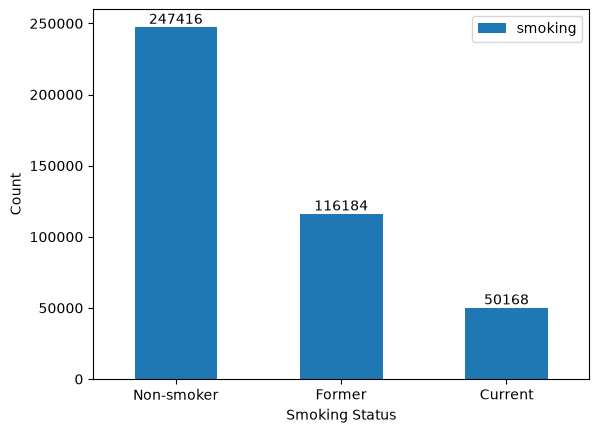

In [41]:
smk_summary = pd.DataFrame({
    "smoking":df["Smoking Status"].value_counts()
})

display(smk_summary)

smk_summary.plot(kind="bar")
for i,value in enumerate(smk_summary.values):
    plt.text(i,value[0],value[0],ha="center",va="bottom")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Chronic Medical Conditions,No,Yes
Smoking Status,,
Current,0.603652,0.396348
Former,0.679947,0.320053
Non-smoker,0.680142,0.319858


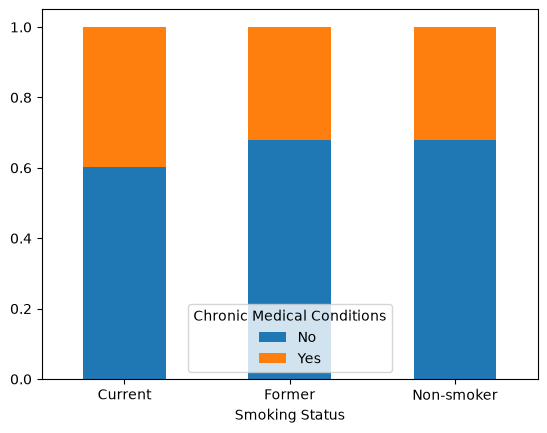

In [43]:
smk_relation_targt = pd.crosstab(
    df["Smoking Status"],
    df["Chronic Medical Conditions"],
    normalize="index"
)

display(smk_relation_targt)

smk_relation_targt.plot(kind="bar",stacked=True)
plt.xticks(rotation=0)
plt.show()

With the help of above data we can say the there is the some relation with smoker and Chronic Medical Conditions. Current smoker have higher percentage of chorinic medical condition as compare to former and non-somker.

**Physical Activity Level**:<br>
The level of physical activity undertaken by the individual. Possible values include Sedentary, Moderate, and Active.


,physical_activity
Physical Activity Level,
Sedentary,176850
Moderate,158013
Active,78905


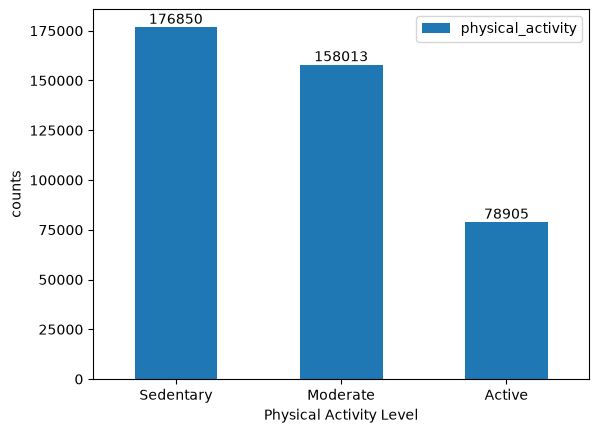

In [49]:
physical_activity_level = pd.DataFrame({
    "physical_activity":df["Physical Activity Level"].value_counts()
})

display(physical_activity_level)


physical_activity_level.plot(kind="bar")

for i,value in enumerate(physical_activity_level.values):
    plt.text(i,value[0],value[0],ha="center",va="bottom")

plt.xticks(rotation=0)
plt.ylabel("counts")
plt.show()

Maximum number of user has very less phycical activity level. Very few number only have active activity.

Chronic Medical Conditions,No,Yes
Physical Activity Level,,
Active,0.657538,0.342462
Moderate,0.655725,0.344275
Sedentary,0.690218,0.309782


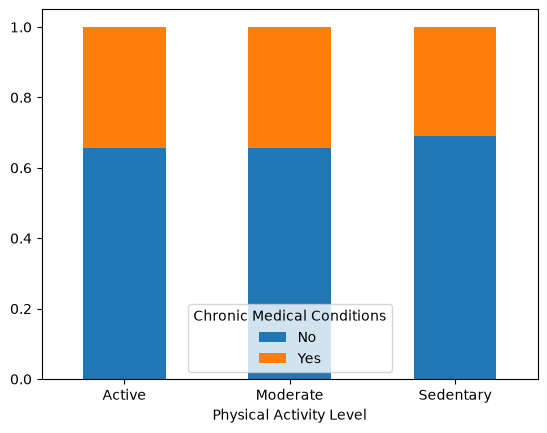

In [50]:
# relation with target column
relation_with_chronic = pd.crosstab(
    df["Physical Activity Level"],
    df["Chronic Medical Conditions"],
    normalize="index"
)

display(relation_with_chronic)

relation_with_chronic.plot(kind="bar",stacked=True)
plt.xticks(rotation=0)
plt.show()

The status for chronic medical condition for all physical activity level is almost similar for moderate and sedentary. Where as active physical activity have better status.

**Employment Status**:<br>
The employment status of the individual. Possible values include Employed and Unemployed.

,emp_status
Employment Status,
Employed,265659
Unemployed,148109


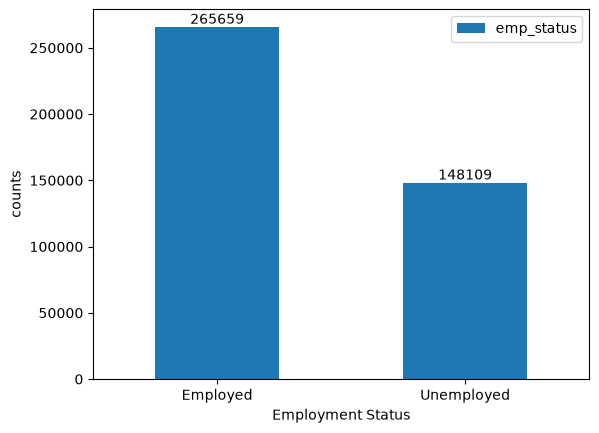

In [ ]:
emp_status = pd.DataFrame({
    "emp_status":df["Employment Status"].value_counts()
})

display(emp_status)


emp_status.plot(kind="bar")

for i,value in enumerate(emp_status.values):
    plt.text(i,value[0],value[0],ha="center",va="bottom")

plt.xticks(rotation=0)
plt.ylabel("counts")
plt.show()

Chronic Medical Conditions,No,Yes
Employment Status,,
Employed,0.685695,0.314305
Unemployed,0.644120,0.355880


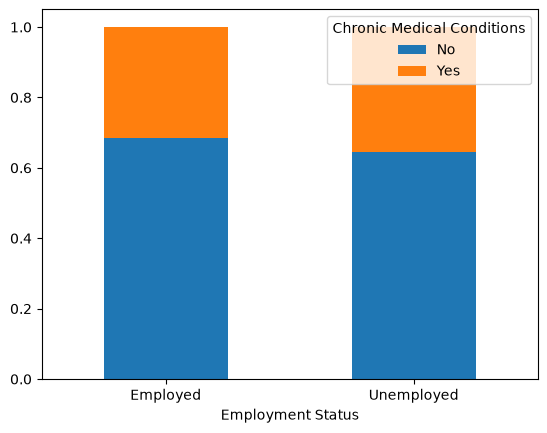

In [53]:
# relation with target column
emp_relation_chronic = pd.crosstab(
    df["Employment Status"],
    df["Chronic Medical Conditions"],
    normalize="index"
)

display(emp_relation_chronic)

emp_relation_chronic.plot(kind="bar",stacked=True)
plt.xticks(rotation=0)
plt.show()

Unemployed has higher chance of chronic medical conditions as compare to employed.

**Income**:<br>
The annual income of the individual in USD.

,income_stat
count,413768.000000
mean,50661.707971
std,40624.100565
min,0.410000
25%,21001.030000
50%,37520.135000
75%,76616.300000
max,209995.220000


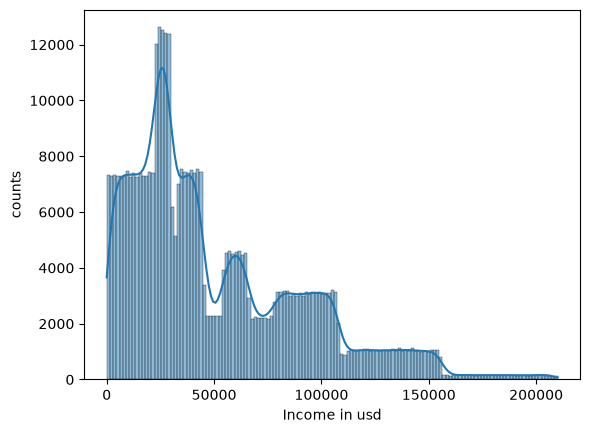

In [59]:
income_stat = pd.DataFrame({
    "income_stat":df["Income"].describe()
})

display(income_stat)
sns.histplot(data=df, x="Income", kde=True)

plt.xticks(rotation=0)
plt.ylabel("counts")
plt.xlabel("Income in usd")
plt.show()

In [62]:
# relation of income with choronic 
relation_with_chronic = df.groupby("Chronic Medical Conditions")["Income"].describe()
display(relation_with_chronic)

,count,mean,std,min,25%,50%,75%,max
Chronic Medical Conditions,,,,,,,,
No,277561.0,51470.676221,40702.943324,0.41,21829.060,38419.64,78174.300,209995.22
Yes,136207.0,49013.202120,40413.018050,1.55,19512.975,35585.91,73016.815,209900.32


With the give stat almost for both class income stat is similar.

**Alcohol Consumption**:<br>
The level of alcohol consumption. Possible values include Low, Moderate, and High.

,alcohol_consumption
Alcohol Consumption,
Moderate,173440
Low,139250
High,101078


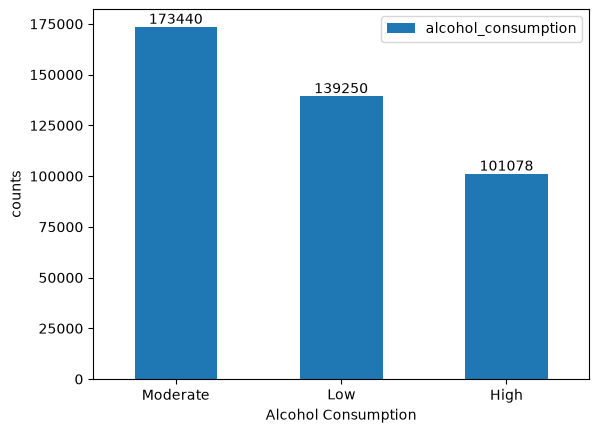

In [64]:
alcohol_consumption = pd.DataFrame({
    "alcohol_consumption":df["Alcohol Consumption"].value_counts()
})

display(alcohol_consumption)


alcohol_consumption.plot(kind="bar")

for i,value in enumerate(alcohol_consumption.values):
    plt.text(i,value[0],value[0],ha="center",va="bottom")

plt.xticks(rotation=0)
plt.ylabel("counts")
plt.show()

Chronic Medical Conditions,No,Yes
Alcohol Consumption,,
High,0.657651,0.342349
Low,0.676151,0.323849
Moderate,0.674199,0.325801


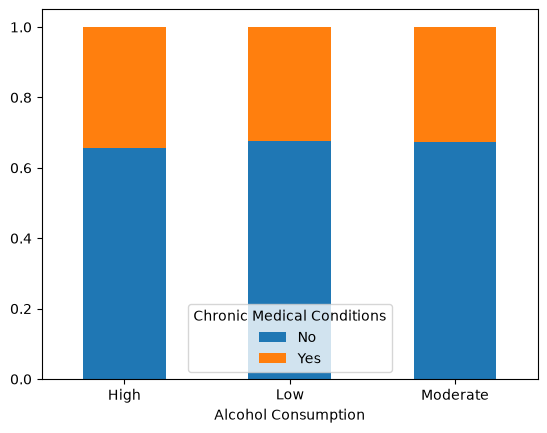

In [65]:
# relation with the target columns:
alcohol_relation_chronic = pd.crosstab(
    df["Alcohol Consumption"],
    df["Chronic Medical Conditions"],
    normalize="index"
)

display(alcohol_relation_chronic)

alcohol_relation_chronic.plot(kind="bar",stacked=True)
plt.xticks(rotation=0)
plt.show()

For all type of alcholol consumption the stat of chronic medical consdition is similar.

**Dietary Habits**:<br>
The dietary habits of the individual. Possible values include Healthy, Moderate, and Unhealthy.

,dietary_habit
Dietary Habits,
Unhealthy,170817
Moderate,170446
Healthy,72505


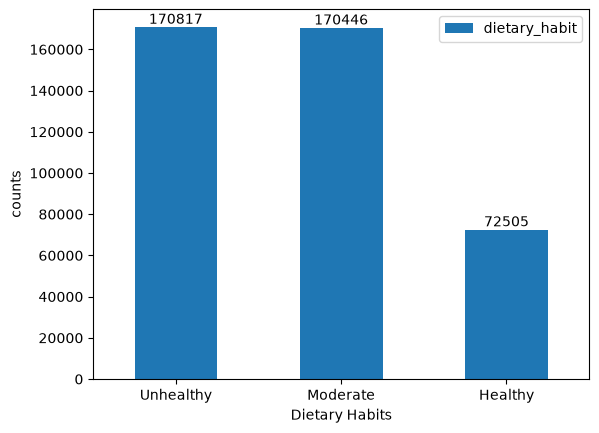

In [66]:
dietary_habit = pd.DataFrame({
    "dietary_habit":df["Dietary Habits"].value_counts()
})

display(dietary_habit)


dietary_habit.plot(kind="bar")

for i,value in enumerate(dietary_habit.values):
    plt.text(i,value[0],value[0],ha="center",va="bottom")

plt.xticks(rotation=0)
plt.ylabel("counts")
plt.show()

With this stat very less number of user are belong to healty dietary.

Chronic Medical Conditions,No,Yes
Dietary Habits,,
Healthy,0.654079,0.345921
Moderate,0.673040,0.326960
Unhealthy,0.675694,0.324306


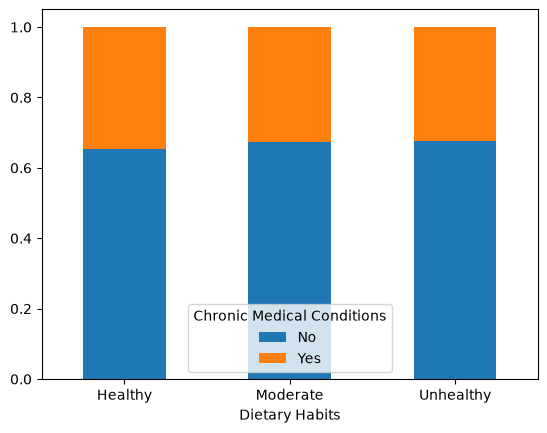

In [67]:
# relation with the target columns:
dietary_relation_chronic = pd.crosstab(
    df["Dietary Habits"],
    df["Chronic Medical Conditions"],
    normalize="index"
)

display(dietary_relation_chronic)

dietary_relation_chronic.plot(kind="bar",stacked=True)
plt.xticks(rotation=0)
plt.show()

For all types of dietary the stat of chronic medical condition is almost similar.

**Sleep Patterns**<br>
The quality of sleep. Possible values include Good, Fair, and Poor.

,sleep_pattern
Sleep Patterns,
Fair,196789
Poor,129582
Good,87397


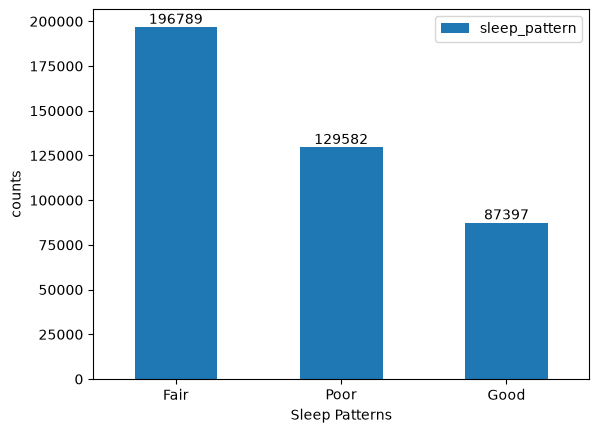

In [68]:
sleep_pattern = pd.DataFrame({
    "sleep_pattern":df["Sleep Patterns"].value_counts()
})

display(sleep_pattern)


sleep_pattern.plot(kind="bar")

for i,value in enumerate(sleep_pattern.values):
    plt.text(i,value[0],value[0],ha="center",va="bottom")

plt.xticks(rotation=0)
plt.ylabel("counts")
plt.show()

Very less number of user have good sleep. 

Chronic Medical Conditions,No,Yes
Sleep Patterns,,
Fair,0.673437,0.326563
Good,0.681431,0.318569
Poor,0.659667,0.340333


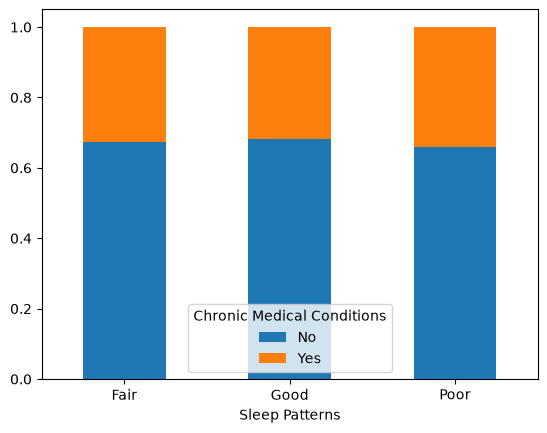

In [69]:
# relation with the target columns:
sleep_relation_chronic = pd.crosstab(
    df["Sleep Patterns"],
    df["Chronic Medical Conditions"],
    normalize="index"
)

display(sleep_relation_chronic)

sleep_relation_chronic.plot(kind="bar",stacked=True)
plt.xticks(rotation=0)
plt.show()

The stat of chronic medical condition is little bit differe for all types sleep status. Poor sleeping cycle have high change of chorinc medica condition where good sleep cycle has very less.

**History of Mental Illness**:<br>
Whether the individual has a history of mental illness. Possible values are Yes and No.

,History of Mental Illness
History of Mental Illness,
No,0.696
Yes,0.304


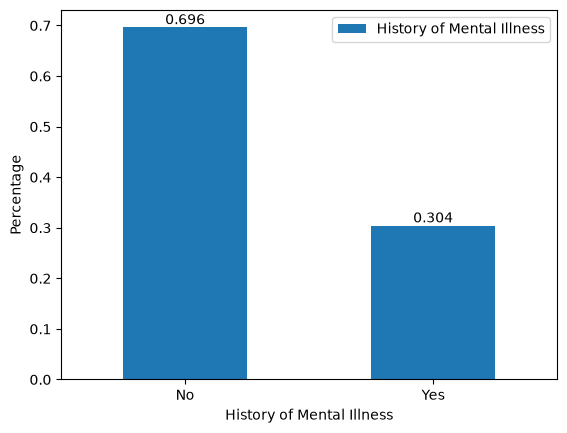

In [76]:
hist_mental_ilness = pd.DataFrame({
    "History of Mental Illness":(df["History of Mental Illness"].value_counts(normalize=True)).round(3)
})

display(hist_mental_ilness)


hist_mental_ilness.plot(kind="bar")

for i,value in enumerate(hist_mental_ilness.values):
    plt.text(i,value[0],value[0],ha="center",va="bottom")

plt.xticks(rotation=0)
plt.ylabel("Percentage")
plt.show()

Almost 70% people has no history of mental illness.

Chronic Medical Conditions,No,Yes
History of Mental Illness,,
No,0.672689,0.327311
Yes,0.666521,0.333479


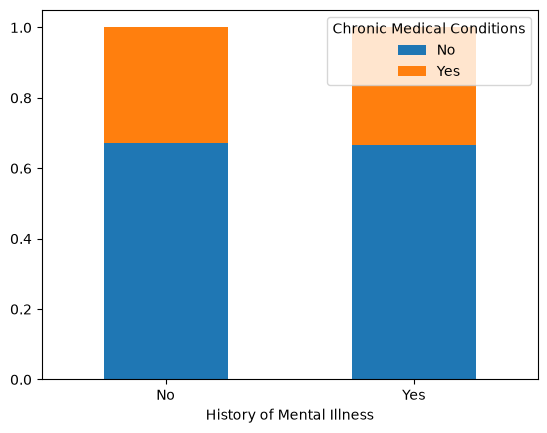

In [74]:
# relation with the target columns:
hist_mental_illness_relation_chronic = pd.crosstab(
    df["History of Mental Illness"],
    df["Chronic Medical Conditions"],
    normalize="index"
)

display(hist_mental_illness_relation_chronic)

hist_mental_illness_relation_chronic.plot(kind="bar",stacked=True)
plt.xticks(rotation=0)
plt.show()

For both user having history of illness and not there is the little bit of differen in stat.

**History of Substance Abuse**:<br>
Whether the individual has a history of substance abuse. Possible values are Yes and No.

,hist_sustance_abuse
History of Substance Abuse,
No,0.689
Yes,0.311


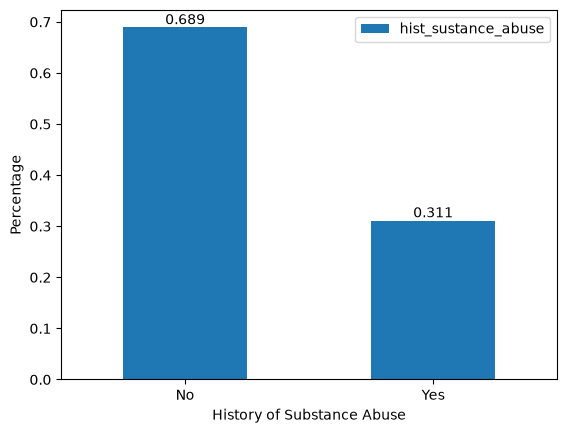

In [ ]:
hist_sustance_abuse = pd.DataFrame({
    "hist_sustance_abuse":(df["History of Substance Abuse"].value_counts(normalize=True)).round(3)
})

display(hist_sustance_abuse)


hist_sustance_abuse.plot(kind="bar")

for i,value in enumerate(hist_sustance_abuse.values):
    plt.text(i,value[0],value[0],ha="center",va="bottom")

plt.xticks(rotation=0)
plt.ylabel("Percentage")
plt.show()

Almost 70% has not history about the substance abuse.

Chronic Medical Conditions,No,Yes
History of Substance Abuse,,
No,0.671858,0.328142
Yes,0.668503,0.331497


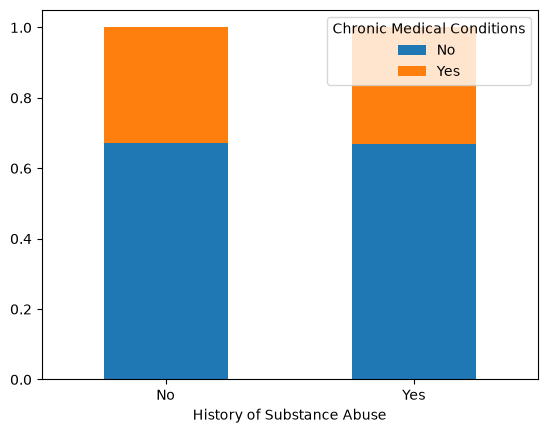

In [78]:
# relation with the target columns:
hist_abuse_relation_chronic = pd.crosstab(
    df["History of Substance Abuse"],
    df["Chronic Medical Conditions"],
    normalize="index"
)

display(hist_abuse_relation_chronic)

hist_abuse_relation_chronic.plot(kind="bar",stacked=True)
plt.xticks(rotation=0)
plt.show()

For both user having history and not have almost similar kind of stat for chronic medical condition.

**Family History of Depression**:<br>
 Indicates if there is a family history of depression. Possible values are Yes and No.

,hist_fm_depression
Family History of Depression,
No,0.731
Yes,0.269


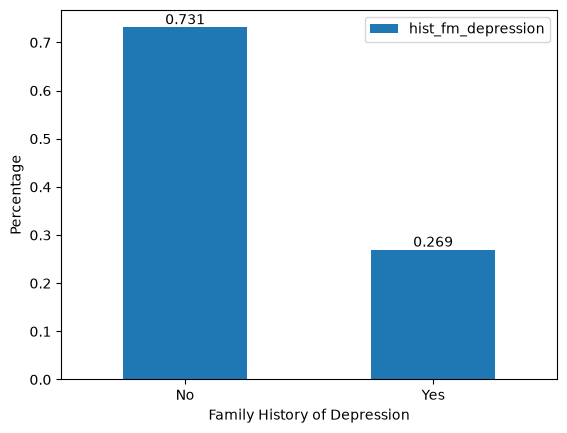

In [79]:
hist_fm_depression = pd.DataFrame({
    "hist_fm_depression":(df["Family History of Depression"].value_counts(normalize=True)).round(3)
})

display(hist_fm_depression)


hist_fm_depression.plot(kind="bar")

for i,value in enumerate(hist_fm_depression.values):
    plt.text(i,value[0],value[0],ha="center",va="bottom")

plt.xticks(rotation=0)
plt.ylabel("Percentage")
plt.show()

Almost 73% user doesn't have history of depression."

Chronic Medical Conditions,No,Yes
Family History of Depression,,
No,0.670165,0.329835
Yes,0.672575,0.327425


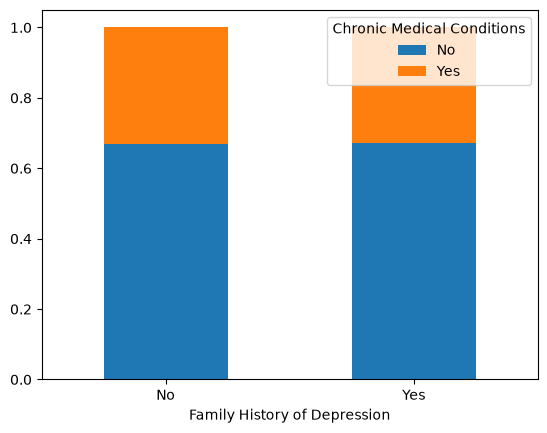

In [80]:
# relation with the target columns:
hist_fm_depression_chronic = pd.crosstab(
    df["Family History of Depression"],
    df["Chronic Medical Conditions"],
    normalize="index"
)

display(hist_fm_depression_chronic)

hist_fm_depression_chronic.plot(kind="bar",stacked=True)
plt.xticks(rotation=0)
plt.show()

For both having history or not have similar kind of stat for chronic medical conditions.